In [1]:
import polars as pl
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pyarrow
import graph_tool.all as gt

In [2]:
df = pl.read_csv("data/output/clean_df.csv")

print(df.head())

shape: (5, 8)
┌────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────┬───────────┐
│ Start date ┆ Start      ┆ End date   ┆ End        ┆ Total      ┆ Operating  ┆ Day of ┆ Hour of   │
│ ---        ┆ station    ┆ ---        ┆ station    ┆ duration   ┆ date       ┆ week   ┆ day       │
│ str        ┆ number     ┆ str        ┆ number     ┆ (ms)       ┆ ---        ┆ ---    ┆ ---       │
│            ┆ ---        ┆            ┆ ---        ┆ ---        ┆ str        ┆ i64    ┆ i64       │
│            ┆ i64        ┆            ┆ i64        ┆ i64        ┆            ┆        ┆           │
╞════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════╪═══════════╡
│ 2025-01-14 ┆ 1043       ┆ 2025-01-15 ┆ 200149     ┆ 870468     ┆ 2025-01-14 ┆ 2      ┆ 23        │
│ T23:59:00. ┆            ┆ T00:13:00. ┆            ┆            ┆            ┆        ┆           │
│ 000000     ┆            ┆ 000000     ┆            ┆            ┆           

In [3]:
# Aggregate trips from station i -> station j
edges = (
    df
    .group_by([
        "Start station number",
        "End station number"
    ])
    .agg(
        pl.len().alias("weight")
    )
    .rename({
        "Start station number": "source",
        "End station number": "target"
    })
    .sort("weight", descending=True)
)

print(edges.head())
print(edges.shape)

shape: (5, 3)
┌────────┬────────┬────────┐
│ source ┆ target ┆ weight │
│ ---    ┆ ---    ┆ ---    │
│ i64    ┆ i64    ┆ u32    │
╞════════╪════════╪════════╡
│ 1075   ┆ 1132   ┆ 3156   │
│ 300213 ┆ 300234 ┆ 2851   │
│ 1132   ┆ 1075   ┆ 2807   │
│ 300234 ┆ 300213 ┆ 2756   │
│ 200038 ┆ 200230 ┆ 2535   │
└────────┴────────┴────────┘
(462168, 3)


In [4]:
stations_start = df.select(
    pl.col("Start station number")
    .drop_nulls()
    .unique()
    .alias("station")
)

stations_end = df.select(
    pl.col("End station number")
    .drop_nulls()
    .unique()
    .alias("station")
)

nodes = (
    pl.concat([stations_start, stations_end])
    .unique()
    .sort("station")
)

print(f"Number of stations : {nodes.height}")

Number of stations : 822


In [5]:
#Create graph

G = nx.DiGraph()

# Add all stations, including stations that might have
# only incoming or only outgoing trips

G.add_nodes_from(nodes["station"].to_list())


# Add weighted directed edges
G.add_weighted_edges_from(
    edges.select(["source", "target", "weight"]).iter_rows()
)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
#Tu as maintenant :
# G = (V,E)

#avec :
#V= stations ;
#E = couples de stations pour lesquels au moins un trajet est observé ;
#Wij= nombre de trajets i vers j

Number of nodes: 822
Number of edges: 462168


In [6]:
#basic descriptions of the graph


#Number of nodes and edges
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()

#Total trips
total_trips = sum(
    data["weight"]
    for _, _, data in G.edges(data=True)
)

print(f"Number of stations: {n_nodes}")
print(f"Number of directed edges: {n_edges}")
print(f"Number of total trips: {total_trips:,}")



#Graph density
density = nx.density(G)

print(f"Directed graph density: {density:.4f}")

Number of stations: 822
Number of directed edges: 462168
Number of total trips: 8,762,355
Directed graph density: 0.6848


In [16]:
##################
#Degree distribution
##################

#Unweighted degree
#This measures the number of different stations connected to a station
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

degree_df = pl.DataFrame({
    "station": list(G.nodes()),
    "in_degree": [in_degree[s] for s in G.nodes()],
    "out_degree": [out_degree[s] for s in G.nodes()],
})

print("In-degree:")
print(degree_df.select("in_degree").describe())

print("Out-degree:")
print(degree_df.select("out_degree").describe())


In-degree:
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ in_degree  │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 822.0      │
│ null_count ┆ 0.0        │
│ mean       ┆ 562.248175 │
│ std        ┆ 128.07283  │
│ min        ┆ 15.0       │
│ 25%        ┆ 483.0      │
│ 50%        ┆ 576.0      │
│ 75%        ┆ 655.0      │
│ max        ┆ 799.0      │
└────────────┴────────────┘
Out-degree:
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ out_degree │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 822.0      │
│ null_count ┆ 0.0        │
│ mean       ┆ 562.248175 │
│ std        ┆ 135.934907 │
│ min        ┆ 0.0        │
│ 25%        ┆ 474.0      │
│ 50%        ┆ 577.0      │
│ 75%        ┆ 665.0      │
│ max        ┆ 807.0      │
└────────────┴────────────┘


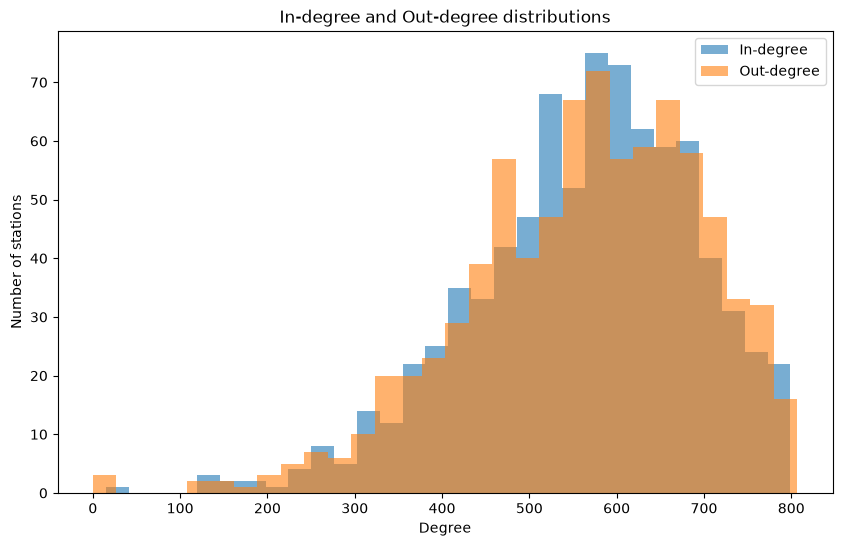

In [13]:
#unweighted plot
plt.figure(figsize=(10, 6))

plt.hist(
    list(in_degree.values()),
    bins=30,
    alpha=0.6,
    label="In-degree"
)

plt.hist(
    list(out_degree.values()),
    bins=30,
    alpha=0.6,
    label="Out-degree"
)

plt.xlabel("Degree")
plt.ylabel("Number of stations")
plt.title("In-degree and Out-degree distributions")
plt.legend()
plt.show()

In [18]:

#Weighted degree / strength
#This gives you the stations generating/receiving the largest numbers of trips.

weighted_in_degree = dict(G.in_degree(weight="weight"))
weighted_out_degree = dict(G.out_degree(weight="weight"))

station_df = pl.DataFrame({
    "station": list(G.nodes()),
    "in_degree": [in_degree[s] for s in G.nodes()],
    "out_degree": [out_degree[s] for s in G.nodes()],
    "weighted_in_degree": [
        weighted_in_degree[s] for s in G.nodes()
    ],
    "weighted_out_degree": [
        weighted_out_degree[s] for s in G.nodes()
    ],
})

print("In-degree weighted:")
print(station_df.select("weighted_in_degree").describe())

print("Out-degree weighted:")
print(station_df.select("weighted_out_degree").describe())


In-degree weighted:
shape: (9, 2)
┌────────────┬────────────────────┐
│ statistic  ┆ weighted_in_degree │
│ ---        ┆ ---                │
│ str        ┆ f64                │
╞════════════╪════════════════════╡
│ count      ┆ 822.0              │
│ null_count ┆ 0.0                │
│ mean       ┆ 10659.79927        │
│ std        ┆ 6626.45292         │
│ min        ┆ 27.0               │
│ 25%        ┆ 6514.0             │
│ 50%        ┆ 9295.0             │
│ 75%        ┆ 13197.0            │
│ max        ┆ 50563.0            │
└────────────┴────────────────────┘
Out-degree weighted:
shape: (9, 2)
┌────────────┬─────────────────────┐
│ statistic  ┆ weighted_out_degree │
│ ---        ┆ ---                 │
│ str        ┆ f64                 │
╞════════════╪═════════════════════╡
│ count      ┆ 822.0               │
│ null_count ┆ 0.0                 │
│ mean       ┆ 10659.79927         │
│ std        ┆ 6262.33475          │
│ min        ┆ 0.0                 │
│ 25%        ┆ 6745.0

In [20]:
#distribution of edge weights
#The edge weight is:
#the number of observed trips from station i to station j.
weights = [
    data["weight"]
    for _, _, data in G.edges(data=True)
]

#descriptive stats
weights_series = pl.Series("weight", weights)

print(weights_series.describe())

#percentiles
print(
    weights_series.quantile(
        [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 462168.0  │
│ null_count ┆ 0.0       │
│ mean       ┆ 18.959242 │
│ std        ┆ 46.05024  │
│ min        ┆ 1.0       │
│ 25%        ┆ 2.0       │
│ 50%        ┆ 6.0       │
│ 75%        ┆ 18.0      │
│ max        ┆ 3156.0    │
└────────────┴───────────┘
[2.0, 6.0, 18.0, 46.0, 78.0, 190.0]


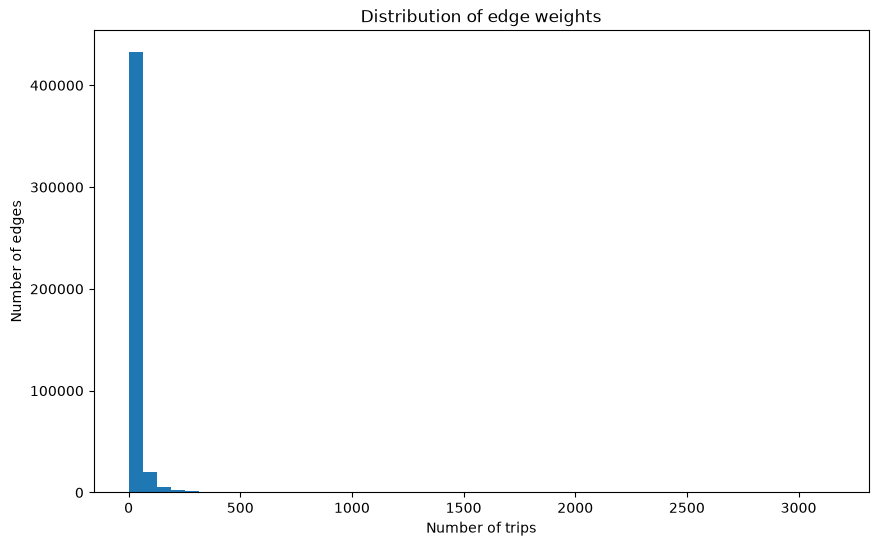

In [21]:
#Edge weights distribution plot
plt.figure(figsize=(10, 6))

plt.hist(weights, bins=50)

plt.xlabel("Number of trips")
plt.ylabel("Number of edges")
plt.title("Distribution of edge weights")

plt.show()

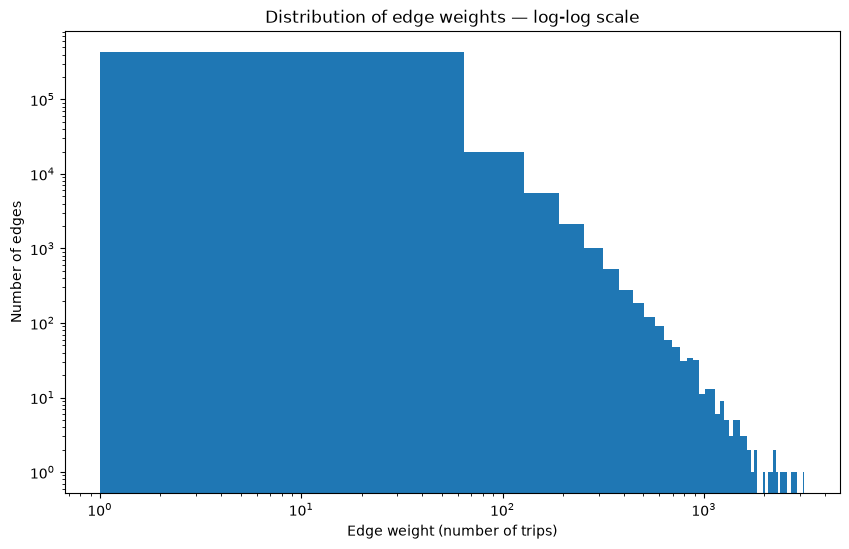

In [22]:
#log graph
plt.figure(figsize=(10, 6))

plt.hist(weights, bins=50)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Edge weight (number of trips)")
plt.ylabel("Number of edges")
plt.title("Distribution of edge weights — log-log scale")

plt.show()

In [23]:
###############
#Central stations
###############
#using degree centrality
degree_centrality = nx.degree_centrality(G)

top_degree = sorted(
    degree_centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top 10 stations by degree centrality:")

for station, value in top_degree:
    print(station, value)

    


Top 10 stations by degree centrality:
1052 1.9500609013398293
995 1.9451887941534713
1160 1.9427527405602922
200128 1.9403166869671131
1011 1.9354445797807551
1151 1.925700365408039
300249 1.925700365408039
3504 1.9244823386114494
960 1.9183922046285018
1028 1.9171741778319122


In [24]:
#Weighted flow centrality
top_inflow = sorted(
    weighted_in_degree.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top 10 stations by incoming flow:")

for station, value in top_inflow:
    print(f"{station}: {value:,} trips")

#Stations with most trips
top_outflow = sorted(
    weighted_out_degree.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top 10 stations by outgoing flow:")

for station, value in top_outflow:
    print(f"{station}: {value:,} trips")

Top 10 stations by incoming flow:
1072: 50,563 trips
2696: 44,261 trips
960: 44,106 trips
1161: 41,383 trips
1067: 40,483 trips
2587: 39,983 trips
22179: 39,072 trips
1052: 38,631 trips
1075: 36,931 trips
200128: 36,538 trips
Top 10 stations by outgoing flow:
1072: 53,880 trips
2696: 46,257 trips
1075: 42,737 trips
2587: 39,851 trips
1011: 38,519 trips
960: 36,539 trips
300083: 33,935 trips
200183: 32,753 trips
1161: 32,640 trips
1132: 31,421 trips


In [26]:
#betweenness
betweenness = nx.betweenness_centrality(
    G,
    weight=None
)

top_betweenness = sorted(
    betweenness.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top 10 stations by betweenness centrality:")

for station, value in top_betweenness:
    print(station, value)


Top 10 stations by betweenness centrality:
995 0.0012152644378142258
22180 0.00115118879636282
960 0.0011347114678882466
1052 0.0011194104624116053
200128 0.0011166201274510482
1160 0.0010870008908144876
1011 0.0010740354265449184
1151 0.0010591485660458573
1007 0.0010509085520720395
999 0.0010423075658604465


In [27]:
G_distance = G.copy()

for u, v, data in G_distance.edges(data=True):
    data["distance"] = 1 / data["weight"]

betweenness_flow = nx.betweenness_centrality(
    G_distance,
    weight="distance"
)

top_betweenness = sorted(
    betweenness_flow.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

for station, value in top_betweenness:
    print(station, value)

1072 0.33923383143697455
2587 0.11848875553310954
1067 0.11186536347702089
1161 0.09419803333234307
200183 0.074682867413327
22179 0.06586405632631236
1011 0.06480793796975728
960 0.0567110305695018
300221 0.056158462315439237
300005 0.054313597338165834


In [28]:
###########################3
#Stations with strong income/outcome imbalance
############################

#For each station:
#imbalance = inflow - outflow

#A positive value means the station receives more trips than it sends.
#A negative value means it sends more trips than it receives.

station_df = station_df.with_columns(
    (
        pl.col("weighted_in_degree")
        - pl.col("weighted_out_degree")
    ).alias("flow_imbalance")
)


#Absolute imbalance
station_df = station_df.with_columns(
    pl.col("flow_imbalance")
    .abs()
    .alias("absolute_imbalance")
)


In [29]:
#Stations with largest positive and negative imbalance

#positive
largest_inflow_imbalance = (
    station_df
    .sort("flow_imbalance", descending=True)
    .head(10)
)

print(largest_inflow_imbalance)


#negative
largest_outflow_imbalance = (
    station_df
    .sort("flow_imbalance")
    .head(10)
)

print(largest_outflow_imbalance)

shape: (10, 7)
┌─────────┬───────────┬────────────┬───────────────┬───────────────┬───────────────┬───────────────┐
│ station ┆ in_degree ┆ out_degree ┆ weighted_in_d ┆ weighted_out_ ┆ flow_imbalanc ┆ absolute_imba │
│ ---     ┆ ---       ┆ ---        ┆ egree         ┆ degree        ┆ e             ┆ lance         │
│ i64     ┆ i64       ┆ i64        ┆ ---           ┆ ---           ┆ ---           ┆ ---           │
│         ┆           ┆            ┆ i64           ┆ i64           ┆ i64           ┆ i64           │
╞═════════╪═══════════╪════════════╪═══════════════╪═══════════════╪═══════════════╪═══════════════╡
│ 1067    ┆ 775       ┆ 777        ┆ 40483         ┆ 28981         ┆ 11502         ┆ 11502         │
│ 982     ┆ 763       ┆ 753        ┆ 30817         ┆ 19593         ┆ 11224         ┆ 11224         │
│ 1161    ┆ 769       ┆ 758        ┆ 41383         ┆ 32640         ┆ 8743          ┆ 8743          │
│ 999     ┆ 785       ┆ 785        ┆ 34731         ┆ 26050         ┆ 8681   

In [30]:
#Overall strongest imbalance
largest_absolute_imbalance = (
    station_df
    .sort("absolute_imbalance", descending=True)
    .head(10)
)

print(largest_absolute_imbalance)


shape: (10, 7)
┌─────────┬───────────┬────────────┬───────────────┬───────────────┬───────────────┬───────────────┐
│ station ┆ in_degree ┆ out_degree ┆ weighted_in_d ┆ weighted_out_ ┆ flow_imbalanc ┆ absolute_imba │
│ ---     ┆ ---       ┆ ---        ┆ egree         ┆ degree        ┆ e             ┆ lance         │
│ i64     ┆ i64       ┆ i64        ┆ ---           ┆ ---           ┆ ---           ┆ ---           │
│         ┆           ┆            ┆ i64           ┆ i64           ┆ i64           ┆ i64           │
╞═════════╪═══════════╪════════════╪═══════════════╪═══════════════╪═══════════════╪═══════════════╡
│ 1067    ┆ 775       ┆ 777        ┆ 40483         ┆ 28981         ┆ 11502         ┆ 11502         │
│ 982     ┆ 763       ┆ 753        ┆ 30817         ┆ 19593         ┆ 11224         ┆ 11224         │
│ 1161    ┆ 769       ┆ 758        ┆ 41383         ┆ 32640         ┆ 8743          ┆ 8743          │
│ 999     ┆ 785       ┆ 785        ┆ 34731         ┆ 26050         ┆ 8681   

In [31]:
#------------------------
#Normalized imbalance
#------------------------

station_df = station_df.with_columns(
    (
        (
            pl.col("weighted_in_degree")
            - pl.col("weighted_out_degree")
        )
        /
        (
            pl.col("weighted_in_degree")
            + pl.col("weighted_out_degree")
        )
    )
    .fill_nan(0)
    .alias("normalized_imbalance")
)

print(
    station_df
    .sort("normalized_imbalance", descending=True)
    .head(10)
)

print(
    station_df
    .sort("normalized_imbalance")
    .head(10)
)

shape: (10, 8)
┌─────────┬───────────┬────────────┬────────────┬────────────┬────────────┬────────────┬───────────┐
│ station ┆ in_degree ┆ out_degree ┆ weighted_i ┆ weighted_o ┆ flow_imbal ┆ absolute_i ┆ normalize │
│ ---     ┆ ---       ┆ ---        ┆ n_degree   ┆ ut_degree  ┆ ance       ┆ mbalance   ┆ d_imbalan │
│ i64     ┆ i64       ┆ i64        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ce        │
│         ┆           ┆            ┆ i64        ┆ i64        ┆ i64        ┆ i64        ┆ ---       │
│         ┆           ┆            ┆            ┆            ┆            ┆            ┆ f64       │
╞═════════╪═══════════╪════════════╪════════════╪════════════╪════════════╪════════════╪═══════════╡
│ 10626   ┆ 354       ┆ 0          ┆ 607        ┆ 0          ┆ 607        ┆ 607        ┆ 1.0       │
│ 22168   ┆ 152       ┆ 0          ┆ 199        ┆ 0          ┆ 199        ┆ 199        ┆ 1.0       │
│ 200226  ┆ 731       ┆ 738        ┆ 18015      ┆ 10824      ┆ 7191       ┆ 

In [32]:
#####################
#Table summary
#####################
station_analysis = station_df.with_columns(
    pl.Series(
        "degree_centrality",
        [
            degree_centrality[s]
            for s in station_df["station"].to_list()
        ]
    ),
    pl.Series(
        "betweenness_centrality",
        [
            betweenness_flow[s]
            for s in station_df["station"].to_list()
        ]
    )
)
print(
    station_analysis
    .sort("weighted_in_degree", descending=True)
    .head(20)
)

shape: (20, 10)
┌─────────┬───────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ station ┆ in_degree ┆ out_degree ┆ weighted_ ┆ … ┆ absolute_ ┆ normalize ┆ degree_ce ┆ betweenne │
│ ---     ┆ ---       ┆ ---        ┆ in_degree ┆   ┆ imbalance ┆ d_imbalan ┆ ntrality  ┆ ss_centra │
│ i64     ┆ i64       ┆ i64        ┆ ---       ┆   ┆ ---       ┆ ce        ┆ ---       ┆ lity      │
│         ┆           ┆            ┆ i64       ┆   ┆ i64       ┆ ---       ┆ f64       ┆ ---       │
│         ┆           ┆            ┆           ┆   ┆           ┆ f64       ┆           ┆ f64       │
╞═════════╪═══════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 1072    ┆ 643       ┆ 696        ┆ 50563     ┆ … ┆ 3317      ┆ -0.031759 ┆ 1.630938  ┆ 0.339234  │
│ 2696    ┆ 783       ┆ 788        ┆ 44261     ┆ … ┆ 1996      ┆ -0.022051 ┆ 1.91352   ┆ 0.03283   │
│ 960     ┆ 794       ┆ 781        ┆ 44106     ┆ … ┆ 7567      ┆ 0.093831  

In [33]:
#Summary statistics
print("=" * 60)
print("DIRECTED WEIGHTED STATION NETWORK — 2025")
print("=" * 60)

print(f"Number of nodes: {G.number_of_nodes():,}")
print(f"Number of edges: {G.number_of_edges():,}")
print(f"Network density: {nx.density(G):.6f}")

print("\nEdge weights:")
print(f"  Minimum: {min(weights):,}")
print(f"  Maximum: {max(weights):,}")
print(f"  Mean:    {np.mean(weights):.2f}")
print(f"  Median:  {np.median(weights):.2f}")

print("\nDegree statistics:")
print(f"  Mean in-degree:  {np.mean(list(in_degree.values())):.2f}")
print(f"  Mean out-degree: {np.mean(list(out_degree.values())):.2f}")
print(f"  Max in-degree:   {max(in_degree.values()):,}")
print(f"  Max out-degree:  {max(out_degree.values()):,}")

DIRECTED WEIGHTED STATION NETWORK — 2025
Number of nodes: 822
Number of edges: 462,168
Network density: 0.684833

Edge weights:
  Minimum: 1
  Maximum: 3,156
  Mean:    18.96
  Median:  6.00

Degree statistics:
  Mean in-degree:  562.25
  Mean out-degree: 562.25
  Max in-degree:   799
  Max out-degree:  807


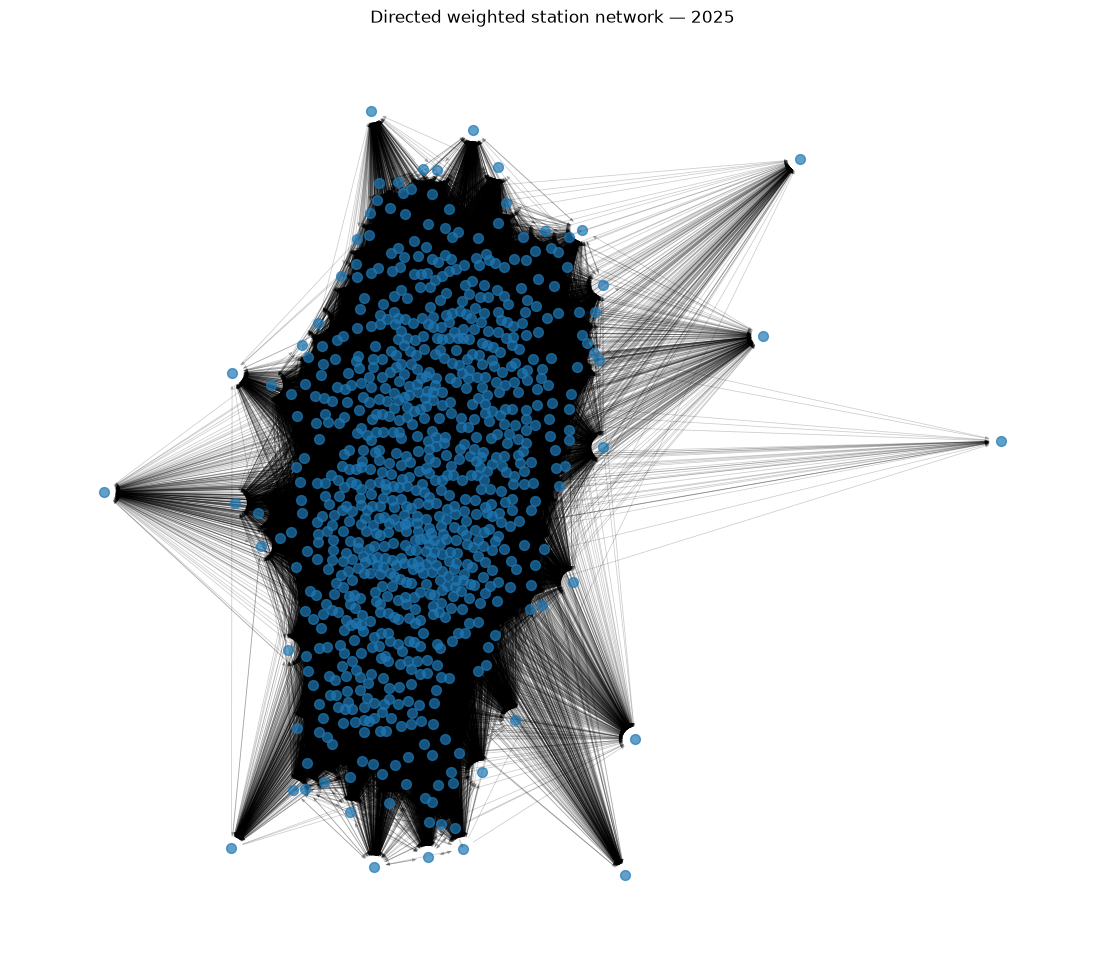

In [34]:
#Network visualization
max_weight = max(weights)

edge_widths = [
    0.5 + 3 * np.sqrt(data["weight"] / max_weight)
    for _, _, data in G.edges(data=True)
]

plt.figure(figsize=(14, 12))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=50,
    alpha=0.7
)

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.2,
    arrows=True,
    arrowsize=5
)

plt.title("Directed weighted station network — 2025")
plt.axis("off")
plt.show()

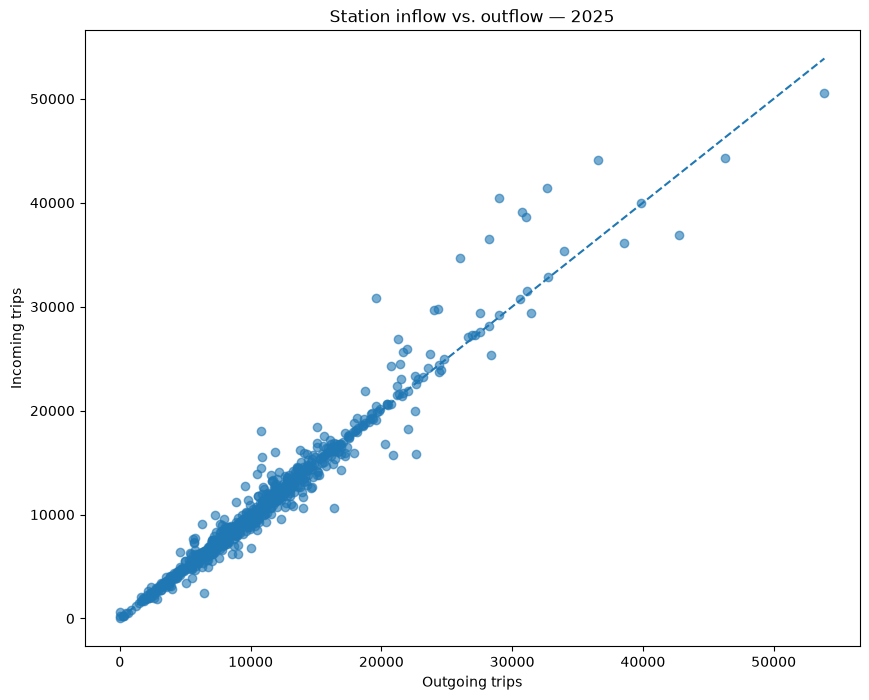

In [35]:
#Inflow vs outflow graph
plot_df = station_analysis.to_pandas()

plt.figure(figsize=(10, 8))

plt.scatter(
    plot_df["weighted_out_degree"],
    plot_df["weighted_in_degree"],
    alpha=0.6
)

max_flow = max(
    plot_df["weighted_out_degree"].max(),
    plot_df["weighted_in_degree"].max()
)

plt.plot(
    [0, max_flow],
    [0, max_flow],
    linestyle="--"
)

plt.xlabel("Outgoing trips")
plt.ylabel("Incoming trips")
plt.title("Station inflow vs. outflow — 2025")

plt.show()

In [38]:
####################
#Stochastic block model
####################

#------------
#Translate to graph-tool
#------------
gt_graph = gt.Graph(directed=True)

# Mapping NetworkX station IDs -> graph-tool vertex IDs
station_to_vertex = {}

for station in G.nodes():
    v = gt_graph.add_vertex()
    station_to_vertex[station] = int(v)

#Add edges
weight_prop = gt_graph.new_edge_property("double")

for source, target, data in G.edges(data=True):

    e = gt_graph.add_edge(
        station_to_vertex[source],
        station_to_vertex[target]
    )

    weight_prop[e] = data["weight"]

gt_graph.edge_properties["weight"] = weight_prop


In [41]:
#Poisson model
state_poisson = gt.minimize_blockmodel_dl(
    gt_graph,
    state_args={
        "recs": [gt_graph.ep.weight],
        "rec_types": ["discrete-poisson"],
        "deg_corr": True,
    }
)

In [42]:
#Inferred number of blocks
print("Number of blocks:", state_poisson.get_nonempty_B())

print("Model entropy:", state_poisson.entropy())

Number of blocks: 809
Model entropy: 2603423.3748664013


In [43]:
#get class assigned to every station
blocks = state.get_blocks()
station_blocks = {}

for station, vertex_id in station_to_vertex.items():
    station_blocks[station] = int(
        blocks[gt_graph.vertex(vertex_id)]
    )

clusters_df = pl.DataFrame({
    "station": list(station_blocks.keys()),
    "block": list(station_blocks.values())
})

print(clusters_df)

shape: (822, 2)
┌────────────┬───────┐
│ station    ┆ block │
│ ---        ┆ ---   │
│ i64        ┆ i64   │
╞════════════╪═══════╡
│ 959        ┆ 349   │
│ 960        ┆ 264   │
│ 961        ┆ 412   │
│ 962        ┆ 316   │
│ 963        ┆ 273   │
│ …          ┆ …     │
│ 200191444  ┆ 815   │
│ 200230444  ┆ 553   │
│ 300032444  ┆ 815   │
│ 300241444  ┆ 492   │
│ 2001454444 ┆ 443   │
└────────────┴───────┘


In [44]:
#Check size of each class
class_sizes = (
    clusters_df
    .group_by("block")
    .agg(
        pl.len().alias("n_stations")
    )
    .sort("n_stations", descending=True)
)

class_sizes = class_sizes.with_columns(
    (
        pl.col("n_stations")
        / pl.col("n_stations").sum()
        * 100
    ).alias("percentage")
)

print(class_sizes)

shape: (93, 3)
┌───────┬────────────┬────────────┐
│ block ┆ n_stations ┆ percentage │
│ ---   ┆ ---        ┆ ---        │
│ i64   ┆ u32        ┆ f64        │
╞═══════╪════════════╪════════════╡
│ 815   ┆ 21         ┆ 2.554745   │
│ 538   ┆ 18         ┆ 2.189781   │
│ 354   ┆ 17         ┆ 2.068127   │
│ 553   ┆ 17         ┆ 2.068127   │
│ 492   ┆ 17         ┆ 2.068127   │
│ …     ┆ …          ┆ …          │
│ 113   ┆ 3          ┆ 0.364964   │
│ 643   ┆ 3          ┆ 0.364964   │
│ 259   ┆ 3          ┆ 0.364964   │
│ 598   ┆ 2          ┆ 0.243309   │
│ 128   ┆ 2          ┆ 0.243309   │
└───────┴────────────┴────────────┘


In [45]:
#SMB with station stats for summary
station_analysis = station_analysis.join(
    clusters_df,
    on="station",
    how="left"
)

block_summary = (
    station_analysis
    .group_by("block")
    .agg([
        pl.len().alias("n_stations"),

        pl.col("in_degree")
        .mean()
        .alias("mean_in_degree"),

        pl.col("out_degree")
        .mean()
        .alias("mean_out_degree"),

        pl.col("weighted_in_degree")
        .mean()
        .alias("mean_inflow"),

        pl.col("weighted_out_degree")
        .mean()
        .alias("mean_outflow"),

        pl.col("flow_imbalance")
        .mean()
        .alias("mean_imbalance"),

        pl.col("normalized_imbalance")
        .mean()
        .alias("mean_normalized_imbalance"),

        pl.col("degree_centrality")
        .mean()
        .alias("mean_degree_centrality"),

        pl.col("betweenness_centrality")
        .mean()
        .alias("mean_betweenness"),
    ])
    .sort("block")
)

print(block_summary)

shape: (93, 10)
┌───────┬────────────┬────────────┬────────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ block ┆ n_stations ┆ mean_in_de ┆ mean_out_d ┆ … ┆ mean_imba ┆ mean_norm ┆ mean_degr ┆ mean_betw │
│ ---   ┆ ---        ┆ gree       ┆ egree      ┆   ┆ lance     ┆ alized_im ┆ ee_centra ┆ eenness   │
│ i64   ┆ u32        ┆ ---        ┆ ---        ┆   ┆ ---       ┆ balance   ┆ lity      ┆ ---       │
│       ┆            ┆ f64        ┆ f64        ┆   ┆ f64       ┆ ---       ┆ ---       ┆ f64       │
│       ┆            ┆            ┆            ┆   ┆           ┆ f64       ┆ f64       ┆           │
╞═══════╪════════════╪════════════╪════════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 22    ┆ 8          ┆ 745.5      ┆ 759.375    ┆ … ┆ 695.625   ┆ 0.027665  ┆ 1.832978  ┆ 0.000244  │
│ 31    ┆ 6          ┆ 754.166667 ┆ 759.166667 ┆ … ┆ 2280.3333 ┆ 0.043739  ┆ 1.843281  ┆ 0.01733   │
│       ┆            ┆            ┆            ┆   ┆ 33        ┆           

In [47]:
#Flow between classes from SBM
edges_with_blocks = edges.with_columns(
    pl.col("source")
    .replace(station_blocks)
    .cast(pl.Int64)
    .alias("source_block"),

    pl.col("target")
    .replace(station_blocks)
    .cast(pl.Int64)
    .alias("target_block")
)

#Add trips
block_flows = (
    edges_with_blocks
    .group_by([
        "source_block",
        "target_block"
    ])
    .agg(
        pl.col("weight").sum().alias("total_trips")
    )
    .sort("total_trips", descending=True)
)

print(block_flows)

#This answers Do the SBM blocks reveal important flows between particular groups of stations?

shape: (8_649, 3)
┌──────────────┬──────────────┬─────────────┐
│ source_block ┆ target_block ┆ total_trips │
│ ---          ┆ ---          ┆ ---         │
│ i64          ┆ i64          ┆ u32         │
╞══════════════╪══════════════╪═════════════╡
│ 326          ┆ 326          ┆ 23069       │
│ 796          ┆ 796          ┆ 17277       │
│ 60           ┆ 326          ┆ 16520       │
│ 341          ┆ 341          ┆ 16322       │
│ 326          ┆ 60           ┆ 16227       │
│ …            ┆ …            ┆ …           │
│ 538          ┆ 389          ┆ 2           │
│ 610          ┆ 257          ┆ 2           │
│ 538          ┆ 677          ┆ 2           │
│ 528          ┆ 610          ┆ 2           │
│ 610          ┆ 387          ┆ 1           │
└──────────────┴──────────────┴─────────────┘


In [48]:
#Block to block flow matrix
flow_matrix = (
    block_flows
    .pivot(
        on="target_block",
        index="source_block",
        values="total_trips"
    )
    .fill_null(0)
)

print(flow_matrix)

shape: (93, 94)
┌──────────────┬───────┬───────┬───────┬───┬──────┬──────┬──────┬──────┐
│ source_block ┆ 326   ┆ 796   ┆ 341   ┆ … ┆ 598  ┆ 242  ┆ 260  ┆ 128  │
│ ---          ┆ ---   ┆ ---   ┆ ---   ┆   ┆ ---  ┆ ---  ┆ ---  ┆ ---  │
│ i64          ┆ u32   ┆ u32   ┆ u32   ┆   ┆ u32  ┆ u32  ┆ u32  ┆ u32  │
╞══════════════╪═══════╪═══════╪═══════╪═══╪══════╪══════╪══════╪══════╡
│ 326          ┆ 23069 ┆ 67    ┆ 57    ┆ … ┆ 50   ┆ 117  ┆ 165  ┆ 310  │
│ 796          ┆ 37    ┆ 17277 ┆ 9210  ┆ … ┆ 2465 ┆ 261  ┆ 2241 ┆ 164  │
│ 60           ┆ 16520 ┆ 61    ┆ 158   ┆ … ┆ 33   ┆ 306  ┆ 155  ┆ 566  │
│ 341          ┆ 43    ┆ 7731  ┆ 16322 ┆ … ┆ 747  ┆ 302  ┆ 2203 ┆ 218  │
│ 610          ┆ 9581  ┆ 34    ┆ 19    ┆ … ┆ 5    ┆ 64   ┆ 57   ┆ 243  │
│ …            ┆ …     ┆ …     ┆ …     ┆ … ┆ …    ┆ …    ┆ …    ┆ …    │
│ 140          ┆ 663   ┆ 643   ┆ 781   ┆ … ┆ 217  ┆ 825  ┆ 1074 ┆ 1469 │
│ 260          ┆ 114   ┆ 2521  ┆ 2179  ┆ … ┆ 514  ┆ 238  ┆ 985  ┆ 239  │
│ 195          ┆ 594   ┆ 420   ┆ 34

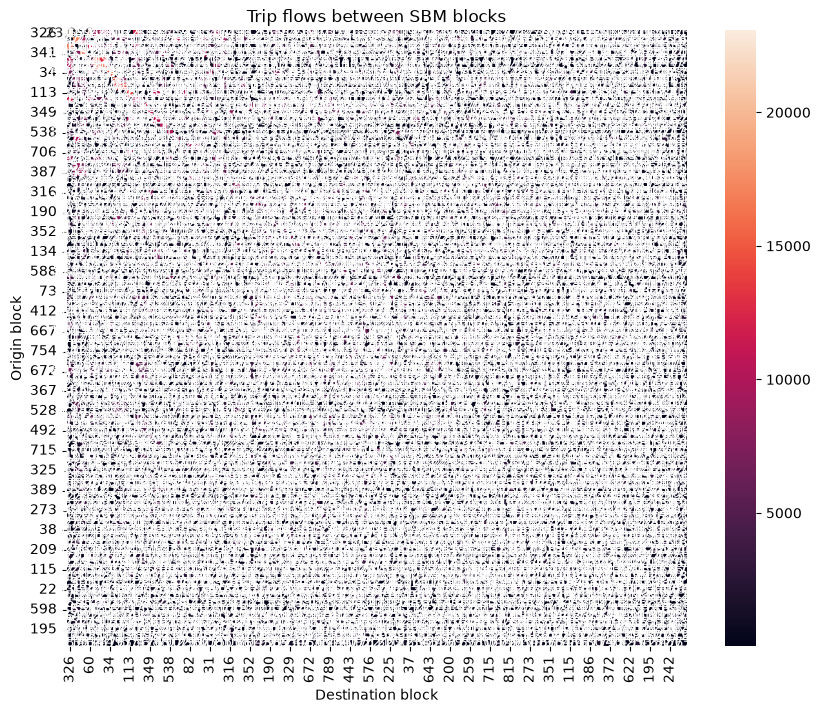

In [49]:
#plot flow matrix
flow_pd = flow_matrix.to_pandas().set_index("source_block")

plt.figure(figsize=(10, 8))

sns.heatmap(
    flow_pd,
    annot=True,
    fmt=",.0f"
)

plt.xlabel("Destination block")
plt.ylabel("Origin block")
plt.title("Trip flows between SBM blocks")

plt.show()

In [50]:
#Run model several times
results = []

for seed in range(10):

    np.random.seed(seed)

    state_i = gt.minimize_blockmodel_dl(
        gt_graph,
        state_args={
            "recs": [gt_graph.ep.weight],
            "rec_types": ["discrete-poisson"],
            "deg_corr": True,
        }
    )

    results.append({
        "run": seed,
        "n_blocks": state_i.get_nonempty_B(),
        "entropy": state_i.entropy(),
    })

print(pl.DataFrame(results))

shape: (10, 3)
┌─────┬──────────┬──────────┐
│ run ┆ n_blocks ┆ entropy  │
│ --- ┆ ---      ┆ ---      │
│ i64 ┆ i64      ┆ f64      │
╞═════╪══════════╪══════════╡
│ 0   ┆ 808      ┆ 2.6039e6 │
│ 1   ┆ 810      ┆ 2.6044e6 │
│ 2   ┆ 802      ┆ 2.6044e6 │
│ 3   ┆ 809      ┆ 2.6035e6 │
│ 4   ┆ 806      ┆ 2.6051e6 │
│ 5   ┆ 804      ┆ 2.6038e6 │
│ 6   ┆ 809      ┆ 2.6035e6 │
│ 7   ┆ 811      ┆ 2.6044e6 │
│ 8   ┆ 811      ┆ 2.6041e6 │
│ 9   ┆ 806      ┆ 2.6041e6 │
└─────┴──────────┴──────────┘
